<a href="https://colab.research.google.com/github/0xfffddd/Coding/blob/main/models_with_history_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

from xgboost import XGBClassifier

import shap

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

DATA_DIR = "."
CLIP_FEATURES_PATH = os.path.join(DATA_DIR, "clip_features.csv")
HISTORY_PATH = os.path.join(DATA_DIR, "dataset_history.csv")
NEW_PRODUCTS_PATH = os.path.join(DATA_DIR, "dataset_new.csv")

NORMALIZED_FEATURES = [
    "trend_score_01",
    "visual_score_01",
    "premium_score_01",
    "unique_score_01",
    "youth_score_01",
]

RAW_FEATURES = [
    "trend_score",
    "visual_score",
    "premium_score",
    "unique_score",
    "youth_score",
]

ID_COLUMNS = ["image_id", "image_path"]
NON_FEATURE_COLUMNS = ID_COLUMNS + ["image_filename", "title", "price"]

POSSIBLE_TARGET_COLUMNS = ["ordered", "purchased", "label", "target", "order"]


def find_target_column(df: pd.DataFrame) -> str:
    """Return the name of the binary target column or raise a clear error."""
    for col in POSSIBLE_TARGET_COLUMNS:
        if col in df.columns:
            return col

    raise ValueError(
        "Historical outcome variable is missing. Expected one of the columns "
        f"{POSSIBLE_TARGET_COLUMNS}, but none were found in clip_features.csv. "
        "Add a binary label indicating whether each advertised product received "
        "an order (1) or not (0) before running the modeling steps."
    )


def engineer_features(df: pd.DataFrame, *, include_target: bool = True) -> Tuple[pd.DataFrame, List[str], str | None]:
    missing = [c for c in NORMALIZED_FEATURES if c not in df.columns]
    if missing:
        raise ValueError(
            "The following normalized CLIP feature columns are missing: "
            f"{missing}. Make sure these exist before training or scoring."
        )

    df_fe = df.copy()

    # Interaction features
    df_fe["trend_visual"] = df_fe["trend_score_01"] * df_fe["visual_score_01"]
    df_fe["premium_unique"] = df_fe["premium_score_01"] * df_fe["unique_score_01"]
    df_fe["trend_youth"] = df_fe["trend_score_01"] * df_fe["youth_score_01"]
    df_fe["visual_unique"] = df_fe["visual_score_01"] * df_fe["unique_score_01"]

    # Aggregate features across normalized scores
    base = df_fe[NORMALIZED_FEATURES]
    df_fe["score_mean"] = base.mean(axis=1)
    df_fe["score_max"] = base.max(axis=1)
    df_fe["score_min"] = base.min(axis=1)

    # Remove raw score columns from the feature set
    drop_cols: List[str] = RAW_FEATURES.copy()

    target_col: str | None = None
    if include_target:
        target_col = find_target_column(df_fe)

    if target_col is not None:
        drop_cols.append(target_col)

    drop_cols.extend(NON_FEATURE_COLUMNS)

    df_model = df_fe.drop(columns=[c for c in drop_cols if c in df_fe.columns])

    feature_cols = list(df_model.columns)

    return df_fe, feature_cols, target_col


def precision_at_k(y_true: np.ndarray, y_scores: np.ndarray, k: int) -> float:
    n = len(y_true)
    if n == 0:
        return float("nan")
    k = min(k, n)
    order = np.argsort(-y_scores)[:k]
    return float(np.mean(y_true[order]))


def find_best_threshold(y_true: np.ndarray, y_scores: np.ndarray, *, metric: str = "f1") -> tuple[float, float]:

    thresholds = np.linspace(0.05, 0.95, 181)
    best_t = 0.5
    best_val = -1.0

    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        if metric == "precision":
            val = precision_score(y_true, y_pred, zero_division=0)
        elif metric == "recall":
            val = recall_score(y_true, y_pred, zero_division=0)
        else:
            val = f1_score(y_true, y_pred, zero_division=0)

        if val > best_val:
            best_val = val
            best_t = t

    return float(best_t), float(best_val)


def evaluate_classification(y_true: np.ndarray, y_scores: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_scores),
        "pr_auc": average_precision_score(y_true, y_scores),
    }
    return metrics


def plot_roc_pr_curves(model_scores: Dict[str, np.ndarray], y_true: np.ndarray) -> None:
    plt.figure(figsize=(7, 6))
    for name, scores in model_scores.items():
        fpr, tpr, _ = roc_curve(y_true, scores)
        auc_val = roc_auc_score(y_true, scores)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 6))
    for name, scores in model_scores.items():
        prec, rec, _ = precision_recall_curve(y_true, scores)
        ap = average_precision_score(y_true, scores)
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    baseline = np.mean(y_true)
    plt.hlines(baseline, 0, 1, colors="k", linestyles="--", label=f"Baseline={baseline:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# 1. Load data

# Load CLIP features
clip_df = pd.read_csv(CLIP_FEATURES_PATH)
print(f"Loaded {len(clip_df)} historical products from {CLIP_FEATURES_PATH}")

# Load historical outcomes (orders)
hist_df = pd.read_csv(HISTORY_PATH)
print(f"Loaded {len(hist_df)} rows with outcomes from {HISTORY_PATH}")

# Build a normalized filename key to join the two tables
def _normalize_image_path(path: str) -> str:
    path = str(path).replace("\\", "/")
    return os.path.basename(path)

clip_df["image_filename"] = clip_df["image_path"].apply(_normalize_image_path)
hist_df["image_filename"] = hist_df["image_path"].apply(_normalize_image_path)

# Merge the ordered label (and optional metadata) into the CLIP table
merge_cols = ["image_filename", "ordered"]
for extra_col in ["title", "price"]:
    if extra_col in hist_df.columns:
        merge_cols.append(extra_col)

clip_df = clip_df.merge(hist_df[merge_cols], on="image_filename", how="left")

# Drop any rows that did not find a match in the history file
if clip_df["ordered"].isna().any():
    missing = clip_df.loc[clip_df["ordered"].isna(), ["image_id", "image_path", "image_filename"]]
    print("Warning: some CLIP rows have no matching outcome in dataset_history.csv. They will be dropped from modeling.")
    display(missing.head())
    clip_df = clip_df.dropna(subset=["ordered"])

clip_df["ordered"] = clip_df["ordered"].astype(int)

# Apply feature engineering
clip_fe, feature_cols, target_col = engineer_features(clip_df, include_target=True)

baseline_rate = clip_df[target_col].mean()
print(f"Detected target column: {target_col}")
print(f"Baseline purchase rate: {baseline_rate:.3%}")
print("Number of engineered feature columns:", len(feature_cols))
print("Example feature columns:", feature_cols[:10])

X = clip_fe[feature_cols].values
y = clip_fe[target_col].values.astype(int)

print("Class distribution (0 = no order, 1 = order):")
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt} samples ({cnt / len(y):.3%})")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")

Loaded 331 historical products from ./clip_features.csv
Loaded 331 rows with outcomes from ./dataset_history.csv


,image_id,image_path,image_filename
258,old:image_333,dataset/image/image_333.jpg,image_333.jpg


Detected target column: ordered
Baseline purchase rate: 31.818%
Number of engineered feature columns: 12
Example feature columns: ['trend_score_01', 'visual_score_01', 'premium_score_01', 'unique_score_01', 'youth_score_01', 'trend_visual', 'premium_unique', 'trend_youth', 'visual_unique', 'score_mean']
Class distribution (0 = no order, 1 = order):
  Class 0: 225 samples (68.182%)
  Class 1: 105 samples (31.818%)
Train size: 264, Test size: 66


In [ ]:
# 2. Logistic Regression

neg, pos = np.bincount(y_train)
print(f"Training class counts -> negative: {neg}, positive: {pos}")

log_reg_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                n_jobs=-1,
                solver="lbfgs",
            ),
        ),
    ]
)

param_grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_search = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=param_grid_lr,
    scoring="f1",
    n_jobs=-1,
    cv=cv,
    refit=True,
    verbose=1,
)

lr_search.fit(X_train, y_train)

best_lr = lr_search.best_estimator_
print("Best Logistic Regression params:", lr_search.best_params_)

# Evaluate on test set
lr_test_scores = best_lr.predict_proba(X_test)[:, 1]
lr_test_pred = best_lr.predict(X_test)

lr_metrics = evaluate_classification(y_test, lr_test_scores, lr_test_pred)
print("Logistic Regression test metrics:")
for k, v in lr_metrics.items():
    print(f"  {k}: {v:.4f}")

Training class counts -> negative: 180, positive: 84
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Logistic Regression params: {'clf__C': 10}
Logistic Regression test metrics:
  accuracy: 0.4848
  precision: 0.3143
  recall: 0.5238
  f1: 0.3929
  roc_auc: 0.5508
  pr_auc: 0.3938


In [ ]:
# 3. XGBoost model

neg_train, pos_train = np.bincount(y_train)
scale_pos_weight = neg_train / max(pos_train, 1)
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.3f}")

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)

param_grid_xgb = {
    "n_estimators": [200, 500],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring="f1",
    n_jobs=-1,
    cv=cv,
    refit=True,
    verbose=1,
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
print("Best XGBoost params:", xgb_search.best_params_)

xgb_test_scores = best_xgb.predict_proba(X_test)[:, 1]
xgb_test_pred = best_xgb.predict(X_test)

xgb_metrics = evaluate_classification(y_test, xgb_test_scores, xgb_test_pred)
print("XGBoost test metrics:")
for k, v in xgb_metrics.items():
    print(f"  {k}: {v:.4f}")

scale_pos_weight for XGBoost: 2.143
Fitting 5 folds for each of 48 candidates, totalling 240 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:18:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost params: {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200, 'subsample': 1.0}
XGBoost test metrics:
  accuracy: 0.5303
  precision: 0.3214
  recall: 0.4286
  f1: 0.3673
  roc_auc: 0.5259
  pr_auc: 0.3655


Baseline purchase rate in test set: 31.818%


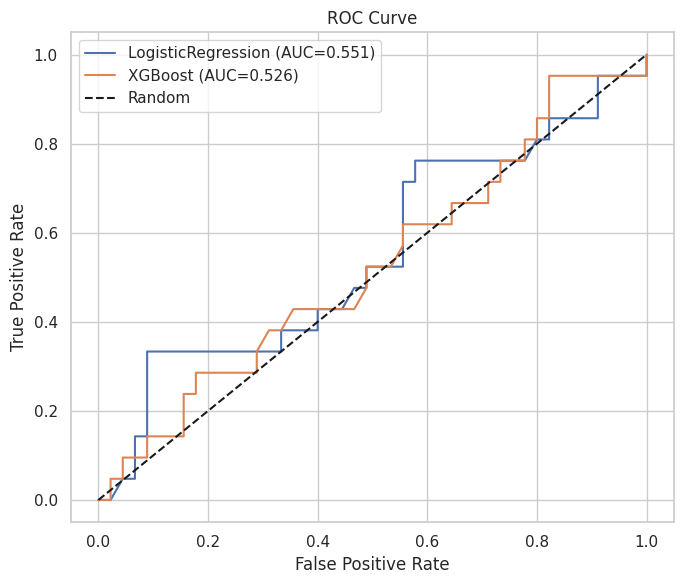

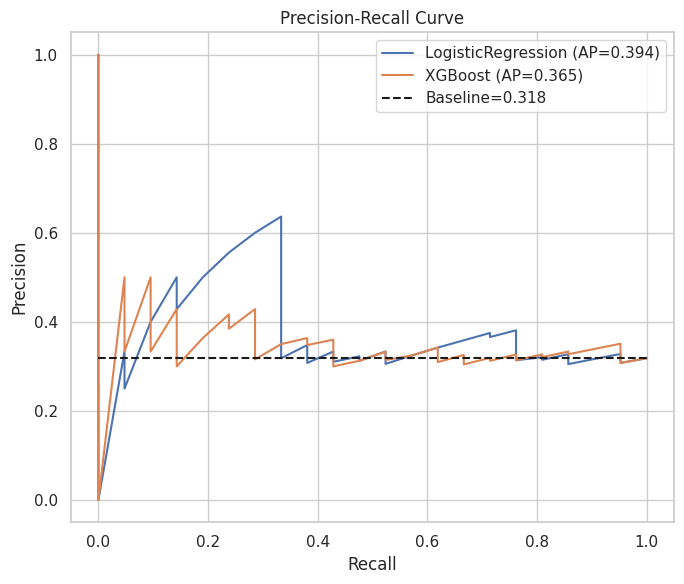


Business Precision@K for LogisticRegression (test set):
  Precision at Top5 products: 40.000%
  Precision at Top10 products: 60.000%
  Precision at Top20 products: 35.000%

Business Precision@K for XGBoost (test set):
  Precision at Top5 products: 40.000%
  Precision at Top10 products: 30.000%
  Precision at Top20 products: 35.000%


In [ ]:
# 4. Model comparison and curves

baseline_rate = y_test.mean()
print(f"Baseline purchase rate in test set: {baseline_rate:.3%}")

comparison_rows = []
for name, metrics in {
    "LogisticRegression": lr_metrics,
    "XGBoost": xgb_metrics,
}.items():
    row = {"model": name}
    row.update(metrics)
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.set_index("model")
comparison_df

# Plot ROC and PR curves
all_scores = {
    "LogisticRegression": lr_test_scores,
    "XGBoost": xgb_test_scores,
}

plot_roc_pr_curves(all_scores, y_test)

# Precision@K evaluation to simulate advertising decisions
for model_name, scores in all_scores.items():
    print(f"\nBusiness Precision@K for {model_name} (test set):")
    for k in [5, 10, 20]:
        p_at_k = precision_at_k(y_test, scores, k)
        print(f"  Precision at Top{k} products: {p_at_k:.3%}")

In [ ]:
# 5. Best Model

# Simple choice: use F1 score; break ties in favor of XGBoost
best_model_name = "XGBoost" if xgb_metrics["f1"] >= lr_metrics["f1"] else "LogisticRegression"
print(f"Selected best model based on F1: {best_model_name}")

if best_model_name == "XGBoost":
    best_model = best_xgb
else:
    best_model = best_lr

# Refit on all labeled data to make use of full history
best_model.fit(X, y)

# Keep feature names for interpretability
feature_names = feature_cols.copy()

Selected best model based on F1: LogisticRegression


Top Logistic Regression coefficients (by absolute value):


,feature,coefficient,abs_coeff
8,visual_unique,2.502780,2.502780
6,premium_unique,-2.237272,2.237272
2,premium_score_01,1.901955,1.901955
1,visual_score_01,-1.754490,1.754490
3,unique_score_01,-0.759464,0.759464
7,trend_youth,0.150556,0.150556
11,score_min,-0.117384,0.117384
4,youth_score_01,0.077271,0.077271
9,score_mean,0.049375,0.049375
5,trend_visual,-0.045122,0.045122


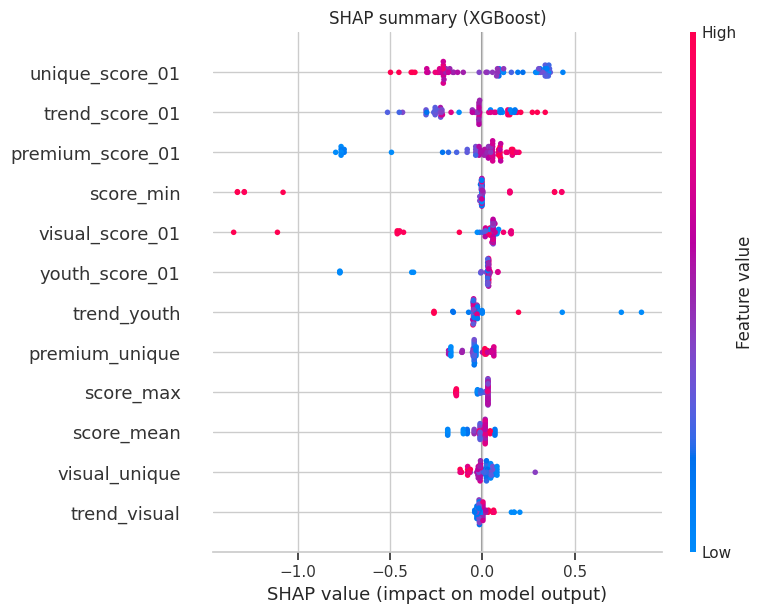

In [ ]:
# 6. SHAP

if isinstance(best_model, Pipeline):
    # Logistic Regression pipeline: get underlying classifier
    lr_clf: LogisticRegression = best_model.named_steps["clf"]
    coefs = lr_clf.coef_.ravel()
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
        "abs_coeff": np.abs(coefs),
    }).sort_values("abs_coeff", ascending=False)

    print("Top Logistic Regression coefficients (by absolute value):")
    display(importance_df.head(15))

else:
    # XGBoost model importance
    xgb_importance = best_model.feature_importances_
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": xgb_importance,
    }).sort_values("importance", ascending=False)

    print("Top XGBoost feature importances:")
    display(importance_df.head(15))

# Optional: SHAP explanations (can be slow on large datasets)
try:
    explainer = shap.TreeExplainer(best_xgb)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
    plt.title("SHAP summary (XGBoost)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("SHAP explanation could not be computed:", e)

In [ ]:
# 7. Score and rank new products

new_df = pd.read_csv(NEW_PRODUCTS_PATH)
print(f"Loaded {len(new_df)} new products from {NEW_PRODUCTS_PATH}")

# Derive an image filename key consistent with clip_features.csv and dataset_history.csv
if "image_path" in new_df.columns:
    new_df["image_filename"] = new_df["image_path"].apply(_normalize_image_path)
else:
    # If no explicit image_path column, assume last column contains the filename
    maybe_path_col = new_df.columns[-1]
    new_df["image_filename"] = new_df[maybe_path_col].apply(_normalize_image_path)

# Load all CLIP features (including new images scored by Clip.py)
clip_all = pd.read_csv(CLIP_FEATURES_PATH)
if "image_filename" not in clip_all.columns:
    clip_all["image_filename"] = clip_all["image_path"].apply(_normalize_image_path)
needed_cols = ["image_filename"] + NORMALIZED_FEATURES
missing_in_clip = [c for c in needed_cols if c not in clip_all.columns]
if missing_in_clip:
    raise ValueError(
        "CLIP features file is missing required columns: "
        f"{missing_in_clip}. Re-run Clip.py to regenerate clip_features.csv."
    )
new_merged = new_df.merge(clip_all[needed_cols], on="image_filename", how="left")
if new_merged[NORMALIZED_FEATURES].isna().any().any():
    missing_rows = new_merged[new_merged[NORMALIZED_FEATURES].isna().any(axis=1)][
        ["image_filename"]
    ].drop_duplicates()
    print("ERROR: Some new products do not have CLIP features in clip_features.csv.")
    print("Missing filenames:")
    display(missing_rows)
else:
    # Apply the same feature engineering pipeline
    new_fe, new_feature_cols, _ = engineer_features(new_merged, include_target=False)
    # Align feature columns with training features
    missing_for_scoring = [c for c in feature_names if c not in new_feature_cols]
    if missing_for_scoring:
        raise ValueError(
            "New products are missing engineered feature columns required by the model: "
            f"{missing_for_scoring}"
        )

    X_new = new_fe[feature_names].values
    new_scores = best_model.predict_proba(X_new)[:, 1]
    results_new = new_merged.copy()
    results_new["predicted_probability"] = new_scores
    results_new["rank"] = (
        results_new["predicted_probability"].rank(ascending=False, method="first").astype(int)
    )
    results_new = results_new.sort_values("predicted_probability", ascending=False)

    # Display key reporting columns
    cols_to_show = []
    for c in ["title", "image_id", "image_path", "image_filename", "predicted_probability", "rank"]:
        if c in results_new.columns:
            cols_to_show.append(c)

    display(results_new[cols_to_show])

Loaded 5 new products from ./dataset_new.csv
ERROR: Some new products do not have CLIP features in clip_features.csv.
Missing filenames:


,image_filename
0,1.jpg
1,2.jpg
2,3.jpg
3,4.jpg
4,5.jpg


In [ ]:
#Prediction on histort.csv with XGBoost
import pandas as pd
import numpy as np


OUT_FILE = "linear_history_predictions.csv"
# Sanity checks
required_vars = ["clip_df", "X", "target_col", "best_model"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"Missing variables in notebook scope: {missing}. "
                    f"Run the previous cells first.")
# Compute predicted probability on HISTORY data points
model = best_model
if hasattr(model, "predict_proba"):
    linear_prob = model.predict_proba(X)[:, 1]
elif hasattr(model, "decision_function"):
    scores = model.decision_function(X)
    linear_prob = 1 / (1 + np.exp(-scores))
else:
    raise AttributeError("best_model has neither predict_proba nor decision_function.")
# Build export dataframe
df = clip_df.copy()

# title may not exist in some versions; create a fallback to avoid KeyError
if "title" not in df.columns:
    df["title"] = df.get("image_filename", df.get("image_path", ""))
# target column may be 'ordered' or something else; normalize to 'order'
export_df = pd.DataFrame({
    "title": df["title"].astype(str).values,
    "order": df[target_col].astype(int).values,
    "linear_prob": linear_prob.astype(float),
})

# Save
export_df.to_csv(OUT_FILE, index=False)
print(f"Saved: {OUT_FILE}")
print(export_df.head())

Saved: linear_history_predictions.csv
                                               title  order  linear_prob
0  Men's Cotton Linen Casual Long Sleeve Shirt Li...      1     0.720365
1         Casual Checked Flannel Shirt White/Red / L      1     0.518081
2           Men's Cotton Long Sleeve Shirt Khaki / L      1     0.599281
3  Men's Linen Resort Casual Button-Down Everyday...      1     0.533798
4  Classic Casual Printed Button Down Cotton Line...      0     0.364551
